In [1]:
import pandas as pd

df = pd.read_csv('SRFG-v1.csv')

print(df.head())
print(df.info())

                  time        lat       long    ele  newpos  rsrq   cell_id  \
0  2018-01-15 16:43:52  47.847847  13.080113  505.1    True  -6.0  798470.0   
1  2018-01-15 16:43:53  47.848070  13.080318  505.2    True  -7.0  798470.0   
2  2018-01-15 16:43:54  47.848280  13.080542  505.5    True  -7.0  798470.0   
3  2018-01-15 16:43:55  47.848484  13.080778  505.7    True  -6.0  798470.0   
4  2018-01-15 16:43:56  47.848680  13.081034  505.8    True  -7.0  798470.0   

   sinr  signal    pci  ...  technology  rsrp   datarate             file  \
0  28.0     5.0  468.0  ...         LTE -65.0  5554624.0  2018-01-15-1736   
1  24.0     5.0  468.0  ...         LTE -68.0  4814816.0  2018-01-15-1736   
2  22.0     5.0  468.0  ...         LTE -67.0  5081632.0  2018-01-15-1736   
3  22.0     5.0  468.0  ...         LTE -70.0  5506112.0  2018-01-15-1736   
4  17.0     5.0  468.0  ...         LTE -77.0  5518240.0  2018-01-15-1736   

   line             trip  predecessor     dlong      dlat  pre

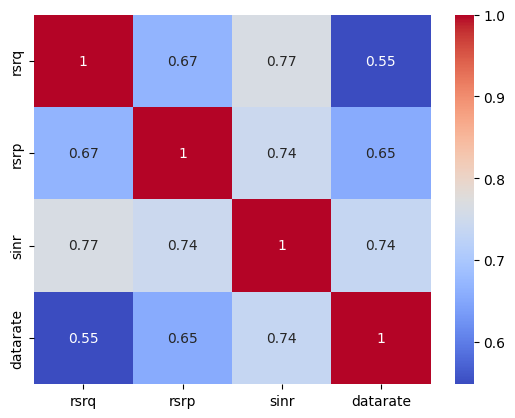

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['rsrq', 'rsrp', 'sinr', 'datarate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# features = ['rsrp', 'sinr', 'datarate']
features = ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
target = 'rsrq'


df_clean = df[features + [target]].dropna()

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = RandomForestRegressor(n_estimators=100, random_state=42)
model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

MAE: 0.77 dB
R2 Score: 0.80


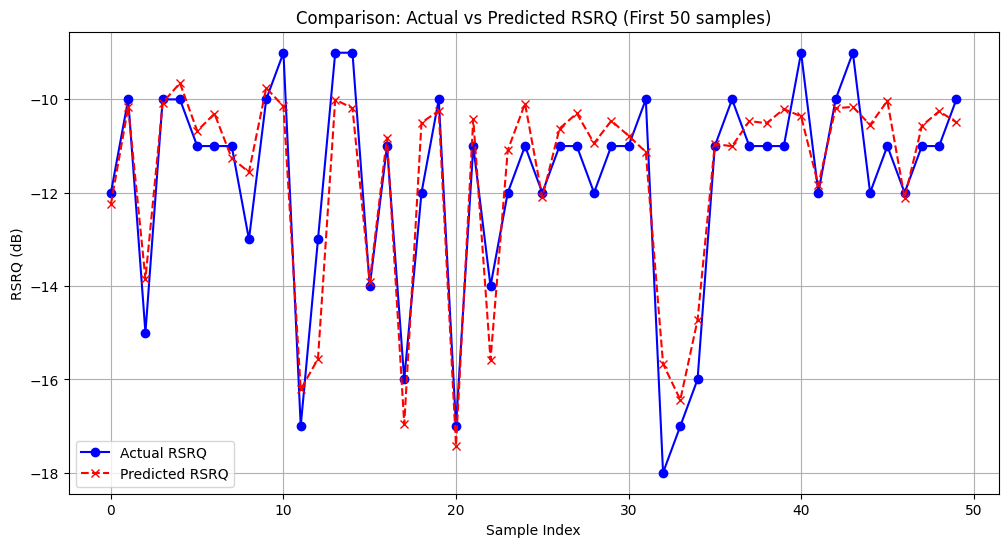

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual RSRQ', marker='o', color='blue')
plt.plot(y_pred[:50], label='Predicted RSRQ', linestyle='--', marker='x', color='red')
plt.title('Comparison: Actual vs Predicted RSRQ (First 50 samples)')
plt.xlabel('Sample Index')
plt.ylabel('RSRQ (dB)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
importances = model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"Feature: {feature}, Importance: {importance:.4f}")

Feature: rsrp, Importance: 0.0493
Feature: sinr, Importance: 0.8044
Feature: datarate, Importance: 0.0601
Feature: dlat, Importance: 0.0392
Feature: dlong, Importance: 0.0469


In [8]:
import joblib

model_filename = 'rsrq_estimator_model.pkl'

joblib.dump(model, model_filename)

print(f"model saved successfully as: {model_filename}.")

model saved successfully as: rsrq_estimator_model.pkl.


In [9]:
import joblib
import pandas as pd

loaded_model = joblib.load('rsrq_estimator_model.pkl')
print("model loaded successfully.")

# df_tehran = pd.read_csv('tehran_drive_test.csv')

# new_data = df_tehran[['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']]

predictions = loaded_model.predict(X_test)
# predictions = loaded_model.predict(new_data)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} dB")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")


model loaded successfully.
MAE: 0.77 dB
R2 Score: 0.80
